# Инициализация

Установим переменные окружения: ```export $(cat .env | xargs)```

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import logging
import logging.handlers
import sys
import os
import boto3
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import sklearn.preprocessing

from dotenv import load_dotenv

load_dotenv()

log_file = logging.FileHandler('logs/research.log', mode='w')
log_file.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))

console_out = logging.StreamHandler(sys.stdout)
console_out.setFormatter(logging.Formatter('%(message)s'))

logger = logging.getLogger()
logger.handlers.clear()

logger.setLevel(level=logging.INFO)
logger.addHandler(log_file)
logger.addHandler(console_out)

s3 = boto3.client('s3', 
    endpoint_url = os.environ.get('MLFLOW_S3_ENDPOINT_URL'),
    aws_access_key_id = os.environ.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key = os.environ.get('AWS_SECRET_ACCESS_KEY'))

S3_BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')
S3_PATH = 'recsys/recommendations'

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
tracks = pd.read_parquet('data/tracks.parquet')
catalog_names = pd.read_parquet('data/catalog_names.parquet')
interactions = pd.read_parquet('data/interactions.parquet')

In [4]:
# Для удобства переименуем колонки
tracks.rename(columns={
    'albums': 'album',
    'genres': 'genre',
    'artists': 'artist'}, inplace=True)

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

tracks

In [5]:
tracks.sample(8).T

,611407,820946,184953,462671,681017,798915,382418,337586
track_id,42611327,64842929,5462397,32244756,49712261,62485232,25763316,21855362
album,"[5635117, 5679469, 6799885]",[10445045],"[601404, 4502139]","[3926509, 4065489, 4593578]",[6832517],"[9857198, 10413409, 13942559]",[3047820],[2511351]
artist,[167267],[7366840],[1042085],"[972, 171413]","[5738948, 6531894, 5766526]",[325682],[3998841],"[3040523, 3806623, 4564321]"
genre,"[19, 325]","[68, 101]","[47, 308]","[26, 74]","[3, 75]","[44, 75]","[47, 161]","[68, 101]"


In [6]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   album     1000000 non-null  object
 2   artist    1000000 non-null  object
 3   genre     1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [7]:
print('Описательная статистика')
tracks.describe().T

Описательная статистика


,count,mean,std,min,25%,50%,75%,max
track_id,1000000.0,3.685121e+07,2.679771e+07,26.0,15430882.75,34550465.5,56925570.75,101521819.0


In [8]:
print('Незаполненные значения')
pd.DataFrame(tracks.isnull().sum()).T

Незаполненные значения


,track_id,album,artist,genre
0,0,0,0,0


In [9]:
# Проверим заполненность имён
tracks_ids = set(tracks['track_id'].unique())
tracks_names = set(catalog_names.query('type == "track"')['id'].unique())
logging.info(f'Количество "track" без имени: {len(tracks_ids - tracks_names)}')

def count_nameless_prop(prop: str):
    '''Рассчитывает количество безымянных значений свойства "prop"'''
    ids_count = set(tracks[[prop]].explode(prop)[prop].unique())
    names_count = set(catalog_names.query('type == @prop')['id'].unique())
    logging.info(f'Количество "{prop}" без имени: {len(ids_count - names_count)}')

count_nameless_prop('album')
count_nameless_prop('genre')
count_nameless_prop('artist')

Количество "track" без имени: 0
Количество "album" без имени: 1
Количество "genre" без имени: 31
Количество "artist" без имени: 1


In [10]:
def max_len_prop(prop: str):
    '''Рассчитывает максимальную длину свойства "prop"'''
    max_len = tracks[['track_id', prop]].explode(prop) \
        .groupby(['track_id']).agg(len=(prop, 'count')).reset_index()['len'].max()
    
    logging.info(f'Максимальная длина свойства "{prop}": {max_len}')

max_len_prop('album')
max_len_prop('genre')
max_len_prop('artist')

Максимальная длина свойства "album": 2844
Максимальная длина свойства "genre": 10
Максимальная длина свойства "artist": 26


In [11]:
# Вычислим количество дубликатов для свойства
def duplicate_count_prop(prop: str, keys: [str] = []):
    '''Рассчитывает количество дубликатов свойства "prop"'''
    duplicate_count = tracks.explode(prop)[keys + [prop]] \
        .merge(catalog_names.query('type == @prop'), left_on=prop, right_on='id') \
        .groupby(keys + ['name']).agg(count=('id', 'nunique')).reset_index() \
        .query('count > 1') \
        ['name'].nunique()
        
    logging.info(f'Количество дубликатов свойства "{prop}": {duplicate_count}')
        
duplicate_count_prop('album', ['track_id'])
duplicate_count_prop('genre')
duplicate_count_prop('artist', ['track_id'])         

Количество дубликатов свойства "album": 47868
Количество дубликатов свойства "genre": 0
Количество дубликатов свойства "artist": 43


catalog_names

In [12]:
catalog_names.sample(8).T

,458854,687342,890056,239193,1385144,1740889,1363085,498974
id,9585446,422980,682734,3710776,39309409,80178786,37929030,11046374
type,album,artist,track,album,track,track,track,album
name,Слёзы любви,Alessandro Benassi,Horsell Common and the Heat Ray,Bonne année 2016,Поезд в сторону Арбатской,Massive Drain,I Have Nothing,Суть


In [13]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [14]:
print('Описательная статистика')
catalog_names.describe().T

Описательная статистика


,count,mean,std,min,25%,50%,75%,max
id,1812471.0,2.321647e+07,2.526044e+07,0.0,3480524.0,12114360.0,37738170.0,101521819.0


In [15]:
print('Незаполненные значения')
pd.DataFrame(catalog_names.isnull().sum()).T

Незаполненные значения


,id,type,name
0,0,0,0


In [16]:
print('Уникальные значения свойства "type"')
pd.DataFrame(catalog_names["type"].value_counts()).T

Уникальные значения свойства "type"


type,track,album,artist,genre
count,1000000,658724,153581,166


interactions

In [17]:
interactions.sample(8).T

,51,426,31,12,21,24,39,1
user_id,403697,768306,606950,816311,988374,68554,985584,622621
track_id,29804870,72610754,17805058,296205,24442536,29456722,63029577,103130
track_seq,52,427,32,13,22,25,40,2
started_at,2022-10-29 00:00:00,2022-11-15 00:00:00,2022-06-07 00:00:00,2022-05-27 00:00:00,2022-02-27 00:00:00,2022-08-24 00:00:00,2022-10-02 00:00:00,2022-08-17 00:00:00


In [18]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [19]:
print('Описательная статистика')
interactions.describe().T

Описательная статистика


,count,mean,min,25%,50%,75%,max,std
user_id,222629898.0,687576.660624,0.0,343371.0,687973.0,1031127.0,1374582.0,396903.293288
track_id,222629898.0,36536224.961649,26.0,14808489.0,35524737.0,56511373.0,101521819.0,26617816.837147
track_seq,222629898.0,462.140293,1.0,56.0,181.0,506.0,16637.0,825.731213
started_at,222629898,2022-08-29 16:39:44.541336320,2022-01-01 00:00:00,2022-07-02 00:00:00,2022-09-15 00:00:00,2022-11-09 00:00:00,2022-12-31 00:00:00,NaN


In [20]:
print('Незаполненные значения')    
pd.DataFrame(interactions.isnull().sum()).T

Незаполненные значения


,user_id,track_id,track_seq,started_at
0,0,0,0,0


In [21]:
msg = 'Количество взаимодействий, для которых нет информации о треках'
val = interactions[~interactions['track_id'].isin(tracks['track_id'].unique())].shape[0]

logging.info(f'{msg}: {val}')

Количество взаимодействий, для которых нет информации о треках: 0


In [22]:
user_track_count = interactions.groupby('user_id').agg(count=('track_id', 'count'), nunique=('track_id', 'nunique')).reset_index()
logging.info(f'Количество пользователей, у которых прослушаны одинаковые треки: {user_track_count.query("count != nunique").shape[0]}')

Количество пользователей, у которых прослушаны одинаковые треки: 0


In [23]:
logging.info(f'Количество уникальных пользователей: {interactions["user_id"].nunique()}')

Количество уникальных пользователей: 1373221


# Выводы

Приведём выводы по первому знакомству с данными:
 - Количество "track" без имени: 0
 - Количество "album" без имени: 1
 - Количество "genre" без имени: 31
 - Количество "artist" без имени: 1
 - Максимальная длина свойства "album": 2844
 - Максимальная длина свойства "genre": 10
 - Максимальная длина свойства "artist": 26
 - Количество дубликатов свойства "album": 47868
 - Количество дубликатов свойства "genre": 0
 - Количество дубликатов свойства "artist": 43
 - Количество взаимодействий, для которых нет информации о треках: 0
 - Количество пользователей, у которых прослушаны одинаковые треки: 0
 - Количество уникальных пользователей: 1373221

Коррекирующие действия выполнены ниже

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

<Axes: xlabel='started_at'>

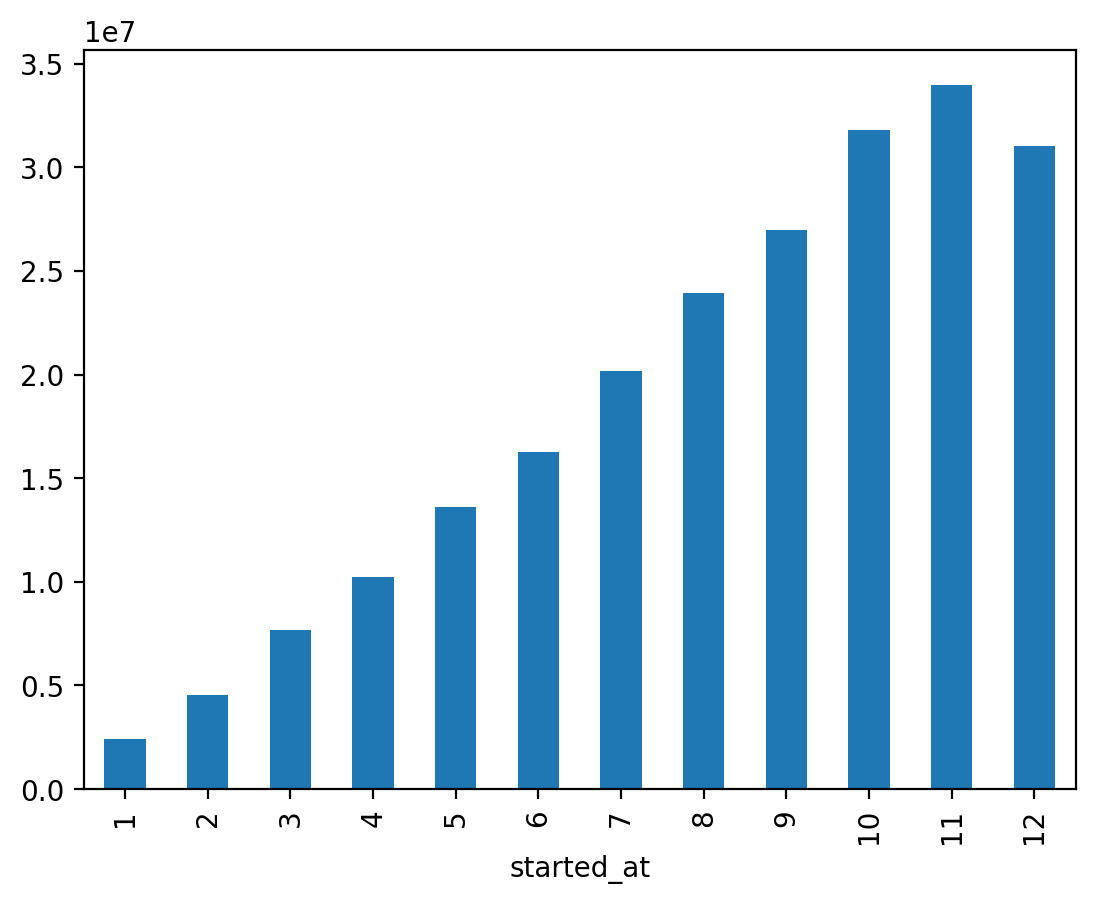

In [24]:
interactions['started_at'].dt.month.value_counts().sort_index().plot(kind='bar')

Наиболее популярные треки

In [25]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .sort_values('votes', ascending=False).head(10) \
    .merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id', how='left')[['name', 'votes']] \
    .set_index([pd.Index(range(1, 11))])

,name,votes
1,Smells Like Teen Spirit,111062
2,Believer,106921
3,Numb,101924
4,I Got Love,99490
5,Юность,86670
6,Way Down We Go,86246
7,Shape of You,85886
8,In The End,85244
9,Shape Of My Heart,85042
10,Life,84748


Наиболее популярные жанры

In [26]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .merge(tracks, on='track_id', how='left')[['votes', 'genre']] \
    .explode('genre') \
    .merge(catalog_names.query('type == "genre"'), left_on='genre', right_on='id', how='left')[['name', 'votes']] \
    .groupby('name').agg(votes=('votes', 'sum')).reset_index() \
    .sort_values('votes', ascending=False) \
    .head(10) \
    .set_index([pd.Index(range(1, 11))])

,name,votes
1,pop,55578312
2,rap,37799821
3,allrock,31092013
4,ruspop,26626241
5,rusrap,25303695
6,electronics,20120981
7,dance,16291557
8,rusrock,13166147
9,rock,12772644
10,metal,12437375


Треки, которые никто не прослушал

In [27]:
tracks[~tracks['track_id'].isin(interactions['track_id'].unique())]

,track_id,album,artist,genre


Неизвестные треки

In [28]:
interactions[~interactions['track_id'].isin(tracks['track_id'].unique())]

,user_id,track_id,track_seq,started_at


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [29]:
# Оставим взаимодействия с известными треками
interactions = interactions[interactions['track_id'].isin(tracks['track_id'].unique())]
# Оставим треки с взаимодейсвиями
tracks = tracks[tracks['track_id'].isin(interactions['track_id'].unique())]

In [30]:
# Рассчитаем количество прослушиваний
tracks = tracks.merge(interactions.groupby(['track_id']).agg(votes=('user_id', 'count')), on='track_id')

In [31]:
# Развернем свойсва, получим имена и удалим безымянные
df_track = tracks.merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id') \
    .reset_index()[['track_id', 'type', 'name', 'votes']]

df_track['id'] = df_track['track_id']

def explode_prop(prop: str):
    '''Разворачивает свойство "prop"'''
    df = tracks.explode(prop)[['track_id', prop, 'votes']] \
        .rename(columns={prop: 'id'}) \
        .merge(catalog_names.query(f'type == "{prop}"'), on='id', how='inner') \
    
    return df[['track_id', 'type', 'id', 'name', 'votes']]  


df_album = explode_prop('album')
df_artist = explode_prop('artist')
df_genre = explode_prop('genre')

In [32]:
# Удалим дубли
def drop_duplicates(df: pd.DataFrame, keys: [str] = []):
    '''Удаляет дубли'''
    df_agg = df.groupby(keys + ['name']).agg(votes=('votes', 'sum')).reset_index()
    df['rank'] = df.groupby(['track_id', 'name']).cumcount() + 1
    df.drop(['votes'], axis=1, inplace=True)
    return df.merge(df_agg, on=keys + ['name']).query('rank == 1')[['track_id', 'id', 'type', 'name', 'votes']]


df_album = drop_duplicates(df_album, ['track_id'])
df_artist = drop_duplicates(df_artist, ['track_id'])
df_genre = drop_duplicates(df_genre)

In [33]:
def calc_rating(votes: np.array, base: int = 10):
    '''Расчитывает рейтинг'''
    scaler = sklearn.preprocessing.MinMaxScaler(feature_range=(0, base))
    return scaler.fit_transform(votes).round(2)


def calc_rating_prop(df: pd.DataFrame):
    '''Расчитывает рейтинг набора'''
    df = df.rename(columns={'votes': 'votes_single'})
        
    votes = df.groupby(['id']).agg(votes=('votes_single', 'sum')).reset_index()
    votes['rating'] = calc_rating(votes[['votes']])
    
    return df.merge(votes, on='id') \
        .drop('votes_single', axis=1)

df_track['rating'] = calc_rating(df_track[['votes']])
df_album = calc_rating_prop(df_album)
df_artist = calc_rating_prop(df_artist)
df_genre = calc_rating_prop(df_genre)

In [34]:
# Удалим не популярные треки
df_track = df_track.query('votes >= 1000')
df_album = df_album[df_album['track_id'].isin(df_track['track_id'].unique())]
df_artist = df_artist[df_artist['track_id'].isin(df_track['track_id'].unique())]
df_genre = df_genre[df_genre['track_id'].isin(df_track['track_id'].unique())]

# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(df_track['track_id'].unique())]

In [35]:
# Сформируем развернутую таблицу треков
tracks = pd.concat([
    df_track,
    df_album,
    df_artist,
    df_genre
]).sort_values('votes', ascending=False)

tracks['rank'] = tracks.groupby(['track_id', 'type']).cumcount() + 1

del df_track, df_album, df_artist, df_genre

gc.collect()

119

In [36]:
# Удалим треки, у которы не все свойства заполнены
incomplete_tracks = tracks.groupby('track_id').agg(prop_count=('type', 'nunique')).reset_index().query('prop_count != 4')
tracks = tracks[~tracks['track_id'].isin(incomplete_tracks['track_id'])]

# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(tracks['track_id'].unique())]

In [37]:
# Оставим по 5 самых популярных значений свойств трека
tracks = tracks.query('rank <= 5')

In [38]:
# Оставим 10 последних взаимодействий для каждого пользователя
interactions['rank'] = interactions.groupby('user_id').cumcount(ascending=False) + 1
interactions = interactions.query('rank <= 10')

# Оставим только актуальные треки
tracks = tracks[tracks['track_id'].isin(interactions['track_id'].unique())]

In [39]:
interactions.shape, tracks.shape

((13023329, 5), (227922, 7))

# EDA преобразованных данных

Распределение количества прослушанных треков.

<Axes: xlabel='started_at'>

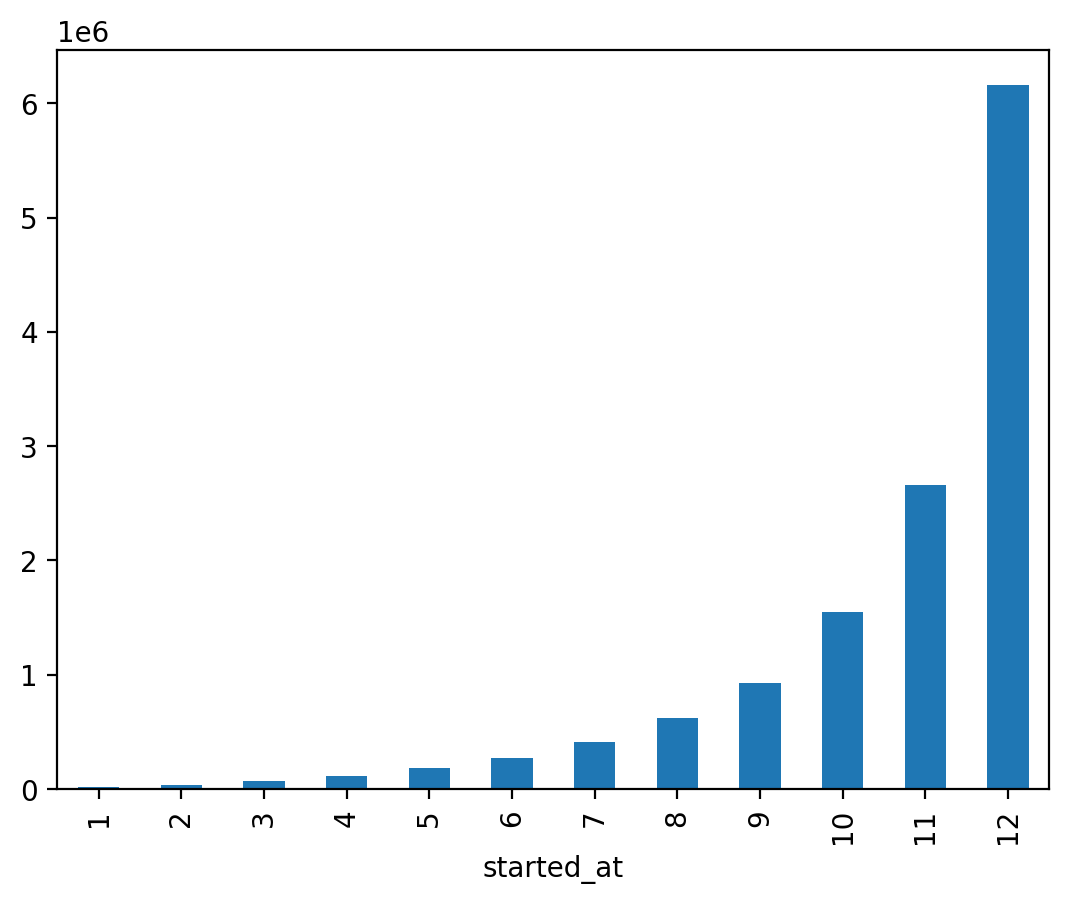

In [40]:
interactions['started_at'].dt.month.value_counts().sort_index().plot(kind='bar')

Наиболее популярные треки

In [41]:
tracks.query('type == "track"').head(10) \
    .merge(tracks.query('type == "artist" & rank == 1')[['track_id', 'name']].rename(columns={'name': 'artist'}), on='track_id') \
    .merge(tracks.query('type == "album" & rank == 1')[['track_id', 'name']].rename(columns={'name': 'album'}), on='track_id') \
    .merge(tracks.query('type == "genre" & rank == 1')[['track_id', 'name']].rename(columns={'name': 'genre'}), on='track_id') \
    .set_index([pd.Index(range(1, 11))]) \
    [['track_id', 'name', 'votes', 'rating', 'artist', 'album', 'genre']]

,track_id,name,votes,rating,artist,album,genre
1,53404,Smells Like Teen Spirit,111062,10.00,Nirvana,Nevermind,allrock
2,33311009,Believer,106921,9.63,Imagine Dragons,Evolve,allrock
3,178529,Numb,101924,9.18,Linkin Park,Meteora,metal
4,35505245,I Got Love,99490,8.96,Miyagi & Эндшпиль,I Got Love,rap
5,65851540,Юность,86670,7.80,Dabro,Юность,pop
6,24692821,Way Down We Go,86246,7.77,KALEO,Summer Music 2016,indie
7,32947997,Shape of You,85886,7.73,Ed Sheeran,Pop,pop
8,51241318,In The End,85244,7.68,Tommee Profitt,Fall Fall Fall,rnb
9,795836,Shape Of My Heart,85042,7.66,Sting,The Best Of 25 Years,pop
10,45499814,Life,84748,7.63,Zivert,Fresh Dance,pop


Наиболее популярные жанры

In [42]:
tracks.query('type == "genre"') \
    [['id', 'name', 'votes', 'rating']] \
    .drop_duplicates() \
    .head(10) \
    .set_index([pd.Index(range(1, 11))])

,id,name,votes,rating
1,11,pop,9241839610920,10.00
2,75,rap,4846390650052,5.24
3,102,allrock,3684683368617,3.99
4,68,electronics,2298721474345,2.49
5,3,rusrap,1668981114810,1.81
6,20,ruspop,1243631838387,1.35
7,47,metal,899359023625,0.97
8,16,dance,841149379467,0.91
9,44,foreignrap,728972206146,0.79
10,14,rock,704756177988,0.76


Треки, которые никто не прослушал

In [43]:
tracks[~tracks['track_id'].isin(interactions['track_id'].unique())]

,track_id,type,name,votes,id,rating,rank


Неизвестные треки

In [44]:
interactions[~interactions['track_id'].isin(tracks['track_id'].unique())]

,user_id,track_id,track_seq,started_at,rank


Распределение рейтингов

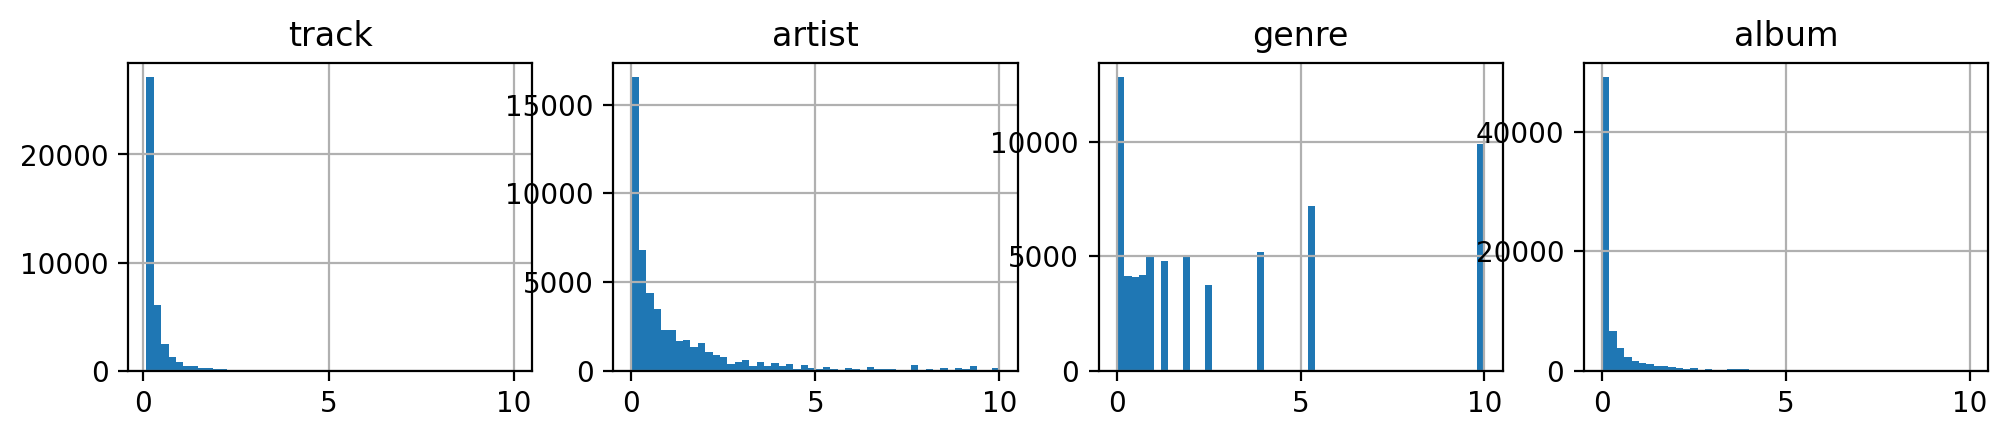

In [45]:
fig, axs = plt.subplots(nrows=1, ncols=4)
fig.set_size_inches(12, 2)

def show_prop_rating(prop: str, ax):
    tracks.query('type == @prop')['rating'].hist(bins=50, ax=ax)
    ax.set_title(prop)

show_prop_rating('track', axs[0])
show_prop_rating('artist', axs[1])
show_prop_rating('genre', axs[2])
show_prop_rating('album', axs[3])

plt.show()

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [46]:
tracks.rename(columns={'track_id': 'item_id'}, inplace=True)
interactions.rename(columns={'track_id': 'item_id'}, inplace=True)

tracks.to_parquet('data/items.parquet')
interactions.to_parquet('data/events.parquet')

s3.upload_file('data/items.parquet', S3_BUCKET_NAME, f'{S3_PATH}/items.parquet')
s3.upload_file('data/events.parquet', S3_BUCKET_NAME, f'{S3_PATH}/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [47]:
del tracks
del interactions
del catalog_names

gc.collect()

570

# === ЭТАП 3 ===

In [48]:
import logging
import sys
import os
import boto3
import scipy
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import sklearn.preprocessing
import sklearn.metrics

from dotenv import load_dotenv
from implicit.als import AlternatingLeastSquares

load_dotenv()

log_file = logging.FileHandler('logs/recs.log', mode='w')
log_file.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))

console_out = logging.StreamHandler(sys.stdout)
console_out.setFormatter(logging.Formatter('%(message)s'))

logger = logging.getLogger()
logger.handlers.clear()

logger.setLevel(level=logging.INFO)
logger.addHandler(log_file)
logger.addHandler(console_out)

s3 = boto3.client('s3', 
    endpoint_url = os.environ.get('MLFLOW_S3_ENDPOINT_URL'),
    aws_access_key_id = os.environ.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key = os.environ.get('AWS_SECRET_ACCESS_KEY'))

S3_BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')
S3_PATH = 'recsys/recommendations'

/home/mle-user/mle_projects/mle-recsys-project/.env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [49]:
s3.download_file(S3_BUCKET_NAME, f'{S3_PATH}/items.parquet', 'data/items.parquet')
s3.download_file(S3_BUCKET_NAME, f'{S3_PATH}/events.parquet', 'data/events.parquet')

items = pd.read_parquet('data/items.parquet')
events = pd.read_parquet('data/events.parquet')

In [50]:
# перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events['user_id'])
events['user_id_enc'] = user_encoder.transform(events['user_id'])

# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items['item_id'])
items['item_id_enc'] = item_encoder.transform(items['item_id'])
events['item_id_enc'] = item_encoder.transform(events['item_id'])

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [51]:
train_split_date = pd.to_datetime('2022-12-16').to_datetime64()

train_split_date_idx = events['started_at'] < train_split_date

events_train = events[train_split_date_idx]
events_test = events[~train_split_date_idx]

events_train.shape, events_test.shape

((9110491, 7), (3912838, 7))

In [52]:
# количество пользователей в train и test
users_train = events_train['user_id'].drop_duplicates()
users_test = events_test['user_id'].drop_duplicates()
# количество пользователей, которые есть и в train, и в test
common_users = set(users_train) & set(users_test)

len(users_train), len(users_test), len(common_users)

(1113710, 702781, 456576)

# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [53]:
item_popularity = events_train \
    .merge(items.query('type == "track"')[['item_id', 'rating']], on='item_id') \
    .groupby(['item_id']).agg(users=('user_id', 'nunique'), rating=('rating', 'mean')).reset_index()

# нормализация пользователей и рейтинга, требуется для их приведения к одному масштабу
scaler = sklearn.preprocessing.MinMaxScaler()
item_popularity[['users_norm', 'rating_norm']] = scaler.fit_transform(
    item_popularity[['users', 'rating']]
)

# вычисляем score, как скор популярности со штрафом за низкий рейтинг
item_popularity['score'] = (
    item_popularity['users_norm'] * item_popularity['rating_norm']
)

# сортируем по убыванию popularity_score
item_popularity = item_popularity.sort_values(by='score', ascending=False)

# выбираем первые 100 айтемов
top_k_pop_items = item_popularity.head(100).set_index([pd.Index(range(1, 101))])
top_k_pop_items['rank'] = top_k_pop_items.index.tolist()

In [54]:
top_k_pop_items

,item_id,users,rating,users_norm,rating_norm,score,rank
1,93126179,23571,5.09,1.000000,0.504541,0.504541,1
2,81848875,17176,6.02,0.728681,0.598385,0.436032,2
3,65851540,12769,7.80,0.541706,0.778002,0.421448,3
4,83063895,15186,6.10,0.644251,0.606458,0.390711,4
5,33311009,9526,9.63,0.404115,0.962664,0.389027,5
...,...,...,...,...,...,...,...
96,17079396,2677,6.72,0.113534,0.669021,0.075957,96
97,23559960,2782,6.40,0.117989,0.636731,0.075127,97
98,55291388,4529,3.96,0.192109,0.390515,0.075021,98
99,41883693,4158,4.27,0.176368,0.421796,0.074391,99


In [55]:
# добавляем имя трека и информацию о жанрах, артистах, альбомах
top_k_pop_items \
    .merge(items.query('type == "track" & rank == 1')[['item_id', 'name']].set_index('item_id'), on='item_id') \
    .merge(items.query('type == "genre" & rank == 1')[['item_id', 'name']].set_index('item_id').rename(columns={'name': 'genre'}), on='item_id') \
    .merge(items.query('type == "artist" & rank == 1')[['item_id', 'name']].set_index('item_id').rename(columns={'name': 'artist'}), on='item_id') \
    .merge(items.query('type == "album" & rank == 1')[['item_id', 'name']].set_index('item_id').rename(columns={'name': 'album'}), on='item_id')

,item_id,users,rating,users_norm,rating_norm,score,rank,name,genre,artist,album
0,93126179,23571,5.09,1.000000,0.504541,0.504541,1,Солнце Монако,pop,Люся Чеботина,The End
1,81848875,17176,6.02,0.728681,0.598385,0.436032,2,Федерико Феллини,pop,Galibri & Mavik,Федерико Феллини
2,65851540,12769,7.80,0.541706,0.778002,0.421448,3,Юность,pop,Dabro,Юность
3,83063895,15186,6.10,0.644251,0.606458,0.390711,4,Птичка,pop,HammAli & Navai,Птичка
4,33311009,9526,9.63,0.404115,0.962664,0.389027,5,Believer,allrock,Imagine Dragons,Evolve
...,...,...,...,...,...,...,...,...,...,...,...
95,17079396,2677,6.72,0.113534,0.669021,0.075957,96,Take Me To Church,indie,Hozier,The Best Braai Album In The World...Ever!
96,23559960,2782,6.40,0.117989,0.636731,0.075127,97,Stressed Out,indie,twenty one pilots,10s Smash Hits
97,55291388,4529,3.96,0.192109,0.390515,0.075021,98,Улетай на крыльях ветра,rap,Dabro remix,Улетай на крыльях ветра
98,41883693,4158,4.27,0.176368,0.421796,0.074391,99,Малиновый свет,pop,Лёша Свик,Autumn Music 2018


In [56]:
top_k_pop_items.to_parquet('data/top_popular.parquet')
s3.upload_file('data/top_popular.parquet', S3_BUCKET_NAME, f'{S3_PATH}/top_popular.parquet')

# Персональные и контентные

Рассчитаем рекомендации.

In [57]:
# создаём sparse-матрицу формата CSR 
def build_csr_matrix(data: pd.DataFrame):
    return scipy.sparse.csr_matrix((
        data['rating'],
        (data['user_id_enc'], data['item_id_enc'])),
        dtype=np.int8) 

In [58]:
def fit_model(csr_matrix):
    model = AlternatingLeastSquares(factors=10, iterations=10, regularization=0.05, random_state=0)
    model.fit(csr_matrix)
    
    return model

In [59]:
def get_recommend(csr_matrix, model, N = 10):
    # получаем список всех возможных user_id (перекодированных)
    user_ids_encoded = range(csr_matrix.shape[0])
    # получаем рекомендации для всех пользователей
    recommendations = model.recommend(
        user_ids_encoded, 
        csr_matrix[user_ids_encoded], 
        filter_already_liked_items=False,
        N=N) 
    
    item_ids_enc = recommendations[0]
    als_scores = recommendations[1]

    df_recommendations = pd.DataFrame({
        'user_id_enc': user_ids_encoded,
        'item_id_enc': item_ids_enc.tolist(), 
        'score': als_scores.tolist()})
    df_recommendations = df_recommendations.explode(['item_id_enc', 'score'], ignore_index=True)

    # приводим типы данных
    df_recommendations['item_id_enc'] = df_recommendations['item_id_enc'].astype('int')
    df_recommendations['score'] = df_recommendations['score'].astype('float')

    # получаем изначальные идентификаторы
    df_recommendations['user_id'] = user_encoder.inverse_transform(df_recommendations['user_id_enc'])
    df_recommendations['item_id'] = item_encoder.inverse_transform(df_recommendations['item_id_enc'])
    df_recommendations = df_recommendations.drop(columns=['user_id_enc', 'item_id_enc'])     
    
    return df_recommendations

In [60]:
def get_type_data(events_data, type_name = '', agg_func = 'mean'):
    '''Формирует набор по событиям'''
    items_agg = (items if type_name == '' else items.query('type == @type_name')) \
        .groupby('item_id').agg(rating=('rating', agg_func)).reset_index()
            
    return events_data[['user_id', 'user_id_enc', 'item_id', 'item_id_enc']] \
        .merge(items_agg, on='item_id', how='left')

In [61]:
def print_sim_track_items(item_id, similar_items):
    '''Показывает похожие'''
    item_columns_to_use = ['item_id', 'name', 'votes', 'rating']
    
    item_id_1 = items.query('type == "track" & item_id == @item_id')[item_columns_to_use] \
        .merge(items.query('type == "genre" & item_id == @item_id & rank == 1')[['item_id', 'name']].rename(columns={'name': 'genre'}), on='item_id', how='left') \
        .merge(items.query('type == "artist" & item_id == @item_id & rank == 1')[['item_id', 'name']].rename(columns={'name': 'artist'}), on='item_id', how='left') \
        .merge(items.query('type == "album" & item_id == @item_id & rank == 1')[['item_id', 'name']].rename(columns={'name': 'album'}), on='item_id', how='left') \
    
    display(item_id_1)
    
    si = similar_items.query('item_id_1 == @item_id')
    si = si.merge(items.query('type == "track"')[item_columns_to_use].set_index('item_id'), left_on='item_id_2', right_index=True) \
        .merge(items.query('type == "genre" & rank == 1')[['item_id', 'name']].set_index('item_id').rename(columns={'name': 'genre'}), left_on='item_id_2', how='left', right_index=True) \
        .merge(items.query('type == "artist" & rank == 1')[['item_id', 'name']].set_index('item_id').rename(columns={'name': 'artist'}), left_on='item_id_2', how='left', right_index=True) \
        .merge(items.query('type == "album" & rank == 1')[['item_id', 'name']].set_index('item_id').rename(columns={'name': 'album'}), left_on='item_id_2', how='left', right_index=True) \

    display(si)

In [62]:
def get_similar_items(model, k = 10):
    '''Получает похожие'''
    # получим энкодированные идентификаторы всех объектов, известных нам из events_train
    train_item_ids_enc = events_train['item_id_enc'].unique()

    # получаем списки похожих объектов, используя ранее полученную ALS-модель
    # метод similar_items возвращает и сам объект, как наиболее похожий
    # этот объект мы позже отфильтруем, но сейчас запросим на 1 больше
    similar_items = model.similar_items(train_item_ids_enc, N=k + 1)

    # преобразуем полученные списки в табличный формат
    sim_item_item_ids_enc = similar_items[0]
    sim_item_scores = similar_items[1]

    similar_items = pd.DataFrame({
        'item_id_enc': train_item_ids_enc,
        'sim_item_id_enc': sim_item_item_ids_enc.tolist(), 
        'score': sim_item_scores.tolist()})
    similar_items = similar_items.explode(['sim_item_id_enc', 'score'], ignore_index=True)

    # приводим типы данных
    similar_items['sim_item_id_enc'] = similar_items['sim_item_id_enc'].astype('int')
    similar_items['score'] = similar_items['score'].astype('float')

    # получаем изначальные идентификаторы
    similar_items['item_id_1'] = item_encoder.inverse_transform(similar_items['item_id_enc'])
    similar_items['item_id_2'] = item_encoder.inverse_transform(similar_items['sim_item_id_enc'])
    similar_items = similar_items.drop(columns=['item_id_enc', 'sim_item_id_enc'])

    # убираем пары с одинаковыми объектами
    similar_items = similar_items.query('item_id_1 != item_id_2')
    
    return similar_items

In [63]:
def get_content_recs(events_data, similar_items, k = 10):
    '''Формирует контентные рекомендации по событиям и похожим'''
    return events_data[['user_id', 'item_id']] \
        .merge(similar_items, left_on='item_id', right_on='item_id_1') \
        [['user_id', 'score', 'item_id_2']] \
        .rename(columns={'item_id_2': 'item_id'}) \
        .sort_values('score', ascending=False) \
        .groupby('user_id').head(k)

In [64]:
events_train_type = get_type_data(events_train, 'track')

csr_matrix_type = build_csr_matrix(events_train_type)
model_type = fit_model(csr_matrix_type)

personal_recs_track = get_recommend(csr_matrix_type, model_type)
similar_items_track = get_similar_items(model_type)
content_recs_track = get_content_recs(events_train, similar_items_track)

personal_recs_track.to_parquet('data/personal_als.parquet')
similar_items_track.to_parquet('data/similar_items.parquet')
content_recs_track.to_parquet('data/similar.parquet')

s3.upload_file('data/personal_als.parquet', S3_BUCKET_NAME, f'{S3_PATH}/personal_als.parquet')
s3.upload_file('data/similar_items.parquet', S3_BUCKET_NAME, f'{S3_PATH}/similar_items.parquet')
s3.upload_file('data/similar.parquet', S3_BUCKET_NAME, f'{S3_PATH}/similar.parquet')

del events_train_type, csr_matrix_type, model_type

gc.collect()

/home/mle-user/mle_projects/mle-recsys-project/.env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 10/10 [00:30<00:00,  3.05s/it]


1041

In [65]:
print_sim_track_items(53404, similar_items_track)

,item_id,name,votes,rating,genre,artist,album
0,53404,Smells Like Teen Spirit,111062,10.0,allrock,Nirvana,Nevermind


,score,item_id_1,item_id_2,name,votes,rating,genre,artist,album
24267,0.997545,53404,36246,Rape Me,29175,2.63,allrock,Nirvana,In Utero
24268,0.996636,53404,57233,The Man Who Sold The World,13688,1.23,allrock,Nirvana,Nirvana
24269,0.995996,53404,53405,Lithium,17682,1.59,allrock,Nirvana,Nevermind
24270,0.990570,53404,53412,Come As You Are,32295,2.91,alternative,Nirvana,Nevermind
24271,0.976745,53404,36234,Heart-Shaped Box,15146,1.36,allrock,Nirvana,Muzică pentru drum - ROCK
24272,0.928717,53404,21168,Tainted Love,13662,1.23,metal,Marilyn Manson,Альтернатива 2000-х
24273,0.890131,53404,42610,Set The World On Fire,12011,1.08,dance,E-Type,Dance Classics & Hits
24274,0.875680,53404,41473,Foxtrot Uniform Charlie Kilo,13595,1.22,allrock,Bloodhound Gang,Gym Pump
24275,0.870965,53404,54994,Crazy,16709,1.50,allrock,Aerosmith,Mega Hits 2021
24276,0.859705,53404,37384,Zombie,80153,7.22,allrock,The Cranberries,Greatest Hits


In [66]:
events_train_type = get_type_data(events_train, 'genre')

csr_matrix_type = build_csr_matrix(events_train_type)
model_type = fit_model(csr_matrix_type)

personal_recs_genre = get_recommend(csr_matrix_type, model_type)
similar_items_genre = get_similar_items(model_type)
content_recs_genre = get_content_recs(events_train, similar_items_genre)

personal_recs_genre.to_parquet('data/personal_als_genre.parquet')
similar_items_genre.to_parquet('data/similar_items_genre.parquet')
content_recs_genre.to_parquet('data/similar_genre.parquet')

s3.upload_file('data/personal_als_genre.parquet', S3_BUCKET_NAME, f'{S3_PATH}/personal_als_genre.parquet')
s3.upload_file('data/similar_items_genre.parquet', S3_BUCKET_NAME, f'{S3_PATH}/similar_items_genre.parquet')
s3.upload_file('data/similar_genre.parquet', S3_BUCKET_NAME, f'{S3_PATH}/similar_genre.parquet')

del events_train_type, csr_matrix_type, model_type

gc.collect()

100%|██████████| 10/10 [00:30<00:00,  3.07s/it]


1008

In [67]:
print_sim_track_items(53404, similar_items_genre)

,item_id,name,votes,rating,genre,artist,album
0,53404,Smells Like Teen Spirit,111062,10.0,allrock,Nirvana,Nevermind


,score,item_id_1,item_id_2,name,votes,rating,genre,artist,album
24267,0.999550,53404,65765,This Is The Life,39791,3.58,pop,Amy Macdonald,Throwback Summer Hits
24268,0.999424,53404,679169,Thunderstruck,43898,3.95,allrock,AC/DC,Iron Man 2
24269,0.998846,53404,560473,Полковнику никто не пишет,57091,5.14,allrock,Би-2,Би-2
24270,0.998535,53404,4427406,The Magic Key,35000,3.15,rap,One-T,The One-T ODC
24271,0.998296,53404,1706563,Danza Kuduro,35484,3.19,pop,Don Omar,She Playing Hella Hard
24272,0.998250,53404,1710818,Don't Stop Me Now,20047,1.80,allrock,Queen,Greatest Hits
24273,0.998197,53404,2214982,Небо славян,17528,1.58,allrock,Алиса,Мы вместе 20 лет
24274,0.998150,53404,17674909,Maria,9535,0.86,allrock,Blondie,Alla tiders hits 80 & 90-talet
24275,0.997910,53404,280530,Personal Jesus,14510,1.31,electronics,Depeche Mode,The Best Of Depeche Mode - Volume One
24276,0.997687,53404,214488,On Mercury,1714,0.15,allrock,Red Hot Chili Peppers,The Studio Album Collection 1991-2011


# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [68]:
# загрузим данные
s3.download_file(S3_BUCKET_NAME, f'{S3_PATH}/personal_als.parquet', 'data/personal_als.parquet')
s3.download_file(S3_BUCKET_NAME, f'{S3_PATH}/personal_als_genre.parquet', 'data/personal_als_genre.parquet')
s3.download_file(S3_BUCKET_NAME, f'{S3_PATH}/similar.parquet', 'data/similar.parquet')
s3.download_file(S3_BUCKET_NAME, f'{S3_PATH}/similar_genre.parquet', 'data/similar_genre.parquet')

personal_als = pd.read_parquet('data/personal_als.parquet')
personal_als_genre = pd.read_parquet('data/personal_als_genre.parquet')
similar = pd.read_parquet('data/similar.parquet')
similar_genre = pd.read_parquet('data/similar_genre.parquet')

In [69]:
# сформируем таблицу кандидатов
candidates = pd.concat([
    personal_als[['user_id', 'item_id', 'score']].rename(columns={'score': 'personal_score'}),
    personal_als_genre[['user_id', 'item_id', 'score']].rename(columns={'score': 'personal_genre_score'}),
    similar[['user_id', 'item_id', 'score']].rename(columns={'score': 'similar_score'}),
    similar_genre[['user_id', 'item_id', 'score']].rename(columns={'score': 'similar_genre_score'})
]).fillna(0).groupby(['user_id', 'item_id']).mean().reset_index()

In [70]:
candidates.sample(5)

,user_id,item_id,personal_score,personal_genre_score,similar_score,similar_genre_score
21548936,679195,34526177,0.000000,0.0,0.998323,0.000000
40281215,1269642,32881674,0.000000,0.0,0.000000,0.999833
33498142,1055700,157291,0.000000,0.0,0.999068,0.000000
4361971,137522,84382282,0.035795,0.0,0.000000,0.000000
26591276,838259,650088,0.000000,0.0,0.999351,0.000000


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [71]:
# задаём точку разбиения
split_date_for_labels = pd.to_datetime('2022-12-29').to_datetime64()

split_date_for_labels_idx = events_test['started_at'] < split_date_for_labels
events_labels = events_test[split_date_for_labels_idx].copy()
events_test_2 = events_test[~split_date_for_labels_idx].copy() 

events_labels.shape, events_test_2.shape

((3169569, 7), (743269, 7))

In [72]:
# добавляем таргет к кандидатам со значением:
# — 1 для тех item_id, которые пользователь слушал
# — 0, для всех остальных 

events_labels['target'] = 1
candidates = candidates.merge(events_labels[['user_id', 'item_id', 'target']], on=['user_id', 'item_id'], how='left')
candidates['target'] = candidates['target'].fillna(0).astype(int)

# в кандидатах оставляем только тех пользователей, у которых есть хотя бы один положительный таргет
candidates_to_sample = candidates[candidates['user_id'].isin(candidates.query('target > 0')['user_id'].unique())]

candidates.drop('target', axis=1, inplace=True)

In [73]:
# для каждого пользователя оставляем только 4 негативных примера
negatives_per_user = 4
candidates_for_train = pd.concat([
    candidates_to_sample.query('target == 1'),
    candidates_to_sample.query('target == 0')
        .groupby('user_id')
        .apply(lambda x: x.sample(negatives_per_user, random_state=0))
    ])

/tmp/ipykernel_18655/3288702361.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(negatives_per_user, random_state=0))


In [74]:
# Обучение модели
from catboost import CatBoostClassifier, Pool

# задаём имена колонок признаков и таргета
features = ['personal_score', 'personal_genre_score', 'similar_score', 'similar_genre_score']
target = 'target'

# Create the Pool object
train_data = Pool(
    data=candidates_for_train[features], 
    label=candidates_for_train[target])

# инициализируем модель CatBoostClassifier
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=100,
    random_seed=0
)

# тренируем модель
cb_model.fit(train_data)

0:	learn: 0.6540275	total: 97.4ms	remaining: 1m 37s
100:	learn: 0.5055207	total: 3.85s	remaining: 34.3s
200:	learn: 0.5032048	total: 7.63s	remaining: 30.4s
300:	learn: 0.5018286	total: 11.5s	remaining: 26.7s
400:	learn: 0.5008606	total: 15.4s	remaining: 23s
500:	learn: 0.5000890	total: 19.3s	remaining: 19.2s
600:	learn: 0.4993588	total: 23.3s	remaining: 15.5s
700:	learn: 0.4987540	total: 27.3s	remaining: 11.6s
800:	learn: 0.4982660	total: 31.3s	remaining: 7.78s
900:	learn: 0.4978051	total: 35.4s	remaining: 3.89s
999:	learn: 0.4974392	total: 39.5s	remaining: 0us


In [75]:
# Ранжирование кандидатов для рекомендаций
candidates_to_rank = candidates[candidates['user_id'].isin(events_test_2['user_id'].unique())]

inference_data = Pool(data=candidates_to_rank[features])
predictions = cb_model.predict_proba(inference_data)

candidates_to_rank['cb_score'] = predictions[:, 1]

# для каждого пользователя проставляем rank, начиная с 1 — это максимальный cb_score
candidates_to_rank = candidates_to_rank.sort_values(['user_id', 'cb_score'], ascending=[True, False])
candidates_to_rank['rank'] = candidates_to_rank.groupby('user_id').cumcount() + 1

max_recommendations_per_user = 100
final_recommendations = candidates_to_rank.query(f'rank <= {max_recommendations_per_user}')

final_recommendations.to_parquet('data/final_recommendations.parquet')
s3.upload_file('data/final_recommendations.parquet', S3_BUCKET_NAME, f'{S3_PATH}/recommendations.parquet')

/tmp/ipykernel_18655/679810966.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates_to_rank['cb_score'] = predictions[:, 1]


In [76]:
final_recommendations.query('user_id == 4')

,user_id,item_id,personal_score,personal_genre_score,similar_score,similar_genre_score,cb_score,rank
192,4,96368212,0.000000e+00,0.072578,0.000000,0.000000,0.401590,1
180,4,83230180,0.000000e+00,0.081401,0.000000,0.000000,0.400788,2
172,4,79694902,0.000000e+00,0.091362,0.000000,0.000000,0.393959,3
188,4,89081846,0.000000e+00,0.078316,0.000000,0.000000,0.389714,4
186,4,86710605,0.000000e+00,0.125466,0.000000,0.000000,0.387516,5
187,4,87662392,0.000000e+00,0.118031,0.000000,0.000000,0.382584,6
183,4,85864771,0.000000e+00,0.071191,0.000000,0.000000,0.379886,7
184,4,86154980,0.000000e+00,0.119765,0.000000,0.000000,0.377209,8
182,4,85150585,0.000000e+00,0.058822,0.000000,0.000000,0.363701,9
191,4,95728483,0.000000e+00,0.059365,0.000000,0.000000,0.363701,10


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [77]:
def process_events_recs_for_binary_metrics(df_events_train, df_events_test, recs, top_k=None):

    '''
    размечает пары <user_id, item_id> для общего множества пользователей признаками
    - gt (ground truth)
    - pr (prediction)
    top_k: расчёт ведётся только для top k-рекомендаций
    '''

    df_events_test['gt'] = True
    common_users = set(df_events_test['user_id']) & set(recs['user_id'])

    common_users_count = len(common_users)
    
    events_for_common_users = df_events_test[df_events_test['user_id'].isin(common_users)].copy()
    recs_for_common_users = recs[recs['user_id'].isin(common_users)].copy()

    recs_for_common_users = recs_for_common_users.sort_values(['user_id', 'score'], ascending=[True, False])

    # оставляет только те item_id, которые были в df_events_train, 
    # т. к. модель не имела никакой возможности давать рекомендации для новых айтемов
    events_for_common_users = events_for_common_users[events_for_common_users['item_id'].isin(df_events_train['item_id'].unique())]

    if top_k is not None:
        recs_for_common_users = recs_for_common_users.groupby('user_id').head(top_k)
    
    events_recs_common = events_for_common_users[['user_id', 'item_id', 'gt']].merge(
        recs_for_common_users[['user_id', 'item_id', 'score']], 
        on=['user_id', 'item_id'], how='outer')    

    events_recs_common['gt'] = events_recs_common['gt'].fillna(False)
    events_recs_common['pr'] = ~events_recs_common['score'].isnull()
    
    events_recs_common['tp'] = events_recs_common['gt'] & events_recs_common['pr']
    events_recs_common['fp'] = ~events_recs_common['gt'] & events_recs_common['pr']
    events_recs_common['fn'] = events_recs_common['gt'] & ~events_recs_common['pr']

    return events_recs_common, common_users_count

In [78]:
def compute_cls_metrics(events_recs_for_binary_metric):
    '''рассчитывает метрики precision и recall'''
    groupper = events_recs_for_binary_metric.groupby('user_id')

    # precision = tp / (tp + fp)
    precision = groupper['tp'].sum()/(groupper['tp'].sum()+groupper['fp'].sum())
    precision = precision.fillna(0).mean()
    
    # recall = tp / (tp + fn)
    recall = groupper['tp'].sum()/(groupper['tp'].sum()+groupper['fn'].sum())
    recall = recall.fillna(0).mean()

    return precision, recall 

In [79]:
def compute_coverage(data, recs):
    '''рссчитывает метрику coverage'''
    return data['user_id'].count() / recs['user_id'].count()

In [80]:
def compute_novelty(df_events_train, recs, top_k = 5):
    '''рссчитывает метрику novelty'''
    # разметим каждую рекомендацию признаком listened
    df_events_train['listened'] = True
    recs = recs.merge(df_events_train[['user_id', 'item_id', 'listened']], on=['user_id', 'item_id'], how='left')
    recs['listened'] = recs['listened'].fillna(False).astype(bool)

    # проставим ранги
    recs = recs.sort_values('listened')
    recs['rank'] = recs.groupby('user_id').cumcount() + 1

    # посчитаем novelty по пользователям
    novelty_k = (1 - recs.query('rank <= @top_k').groupby('user_id')['listened'].mean())

    # посчитаем средний novelty
    novelty = novelty_k.mean()
    
    return novelty

Топ популярных

In [81]:
cold_users = list(set(users_test) - set(users_train))

cold_users_events_with_recs = \
    events_test[events_test['user_id'].isin(cold_users)] \
    .merge(top_k_pop_items, on='item_id', how='left')

cold_user_items_no_avg_rating_idx = cold_users_events_with_recs['rating'].isnull()
cold_user_recs = cold_users_events_with_recs[~cold_user_items_no_avg_rating_idx][['user_id', 'item_id', 'rating']]

# посчитаем покрытие холодных пользователей рекомендациями
cold_users_hit_ratio = cold_users_events_with_recs.groupby('user_id').agg(hits=('rating', lambda x: (~x.isnull()).mean()))

logging.info(f'Доля "холодных" пользователей без релевантных рекомендаций: {(cold_users_hit_ratio == 0).mean().iat[0]:.2f}')
logging.info(f'Среднее покрытие "холодных" пользователей: {cold_users_hit_ratio[cold_users_hit_ratio != 0].mean().iat[0]:.2f}')

Доля "холодных" пользователей без релевантных рекомендаций: 0.58
Среднее покрытие "холодных" пользователей: 0.17


Персональные и контентные, полученные при помощи ALS

In [82]:
def compute_ndcg(rating: pd.Series, score: pd.Series, k):

    ''' подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    '''
    
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(np.asarray([rating.to_numpy()]), np.asarray([score.to_numpy()]), k=k)

    return ndcg 

In [83]:
def calc_ndcg(recs, type_name, k = 5):
    recs = (
        recs.merge(items.query('type == @type_name')[['item_id', 'rating']]
            .rename(columns={'rating': 'rating_test'}), 
            on=['item_id'], how='left')
    )   
    
    ndcg_scores = recs.query('~rating_test.isnull()') \
        .groupby('user_id').apply(lambda x: compute_ndcg(x['rating_test'], x['score'], k=k)) 
        
    return ndcg_scores

In [84]:
# personal_als NDCG@5: 0.9489576425655531
# ndcg_at_5_scores_type = calc_ndcg(personal_als, 'track')
# logging.info(f'personal_als NDCG@5: {ndcg_at_5_scores_type.mean()}')
# del ndcg_at_5_scores_type

In [85]:
# personal_als_genre NDCG@5: 0.9135024869036742
# ndcg_at_5_scores_type = calc_ndcg(personal_als_genre, 'genre')
# logging.info(f'personal_als_genre NDCG@5: {ndcg_at_5_scores_type.mean()}')
# del ndcg_at_5_scores_type

In [86]:
recs = [personal_als, personal_als_genre, similar, similar_genre]
names = ['personal_als', 'personal_als_genre', 'similar', 'similar_genre']

top_k = 5

als_metrics = []
als_metrics_columns=['name', f'precision@{top_k}', f'recall@{top_k}', f'novelty@{top_k}', 'coverage', 'common_users']

for i in range(len(recs)):
    events_recs_for_binary_metrics, common_users_count = process_events_recs_for_binary_metrics(
        events_train.copy(),
        events_test.copy(), 
        recs[i], 
        top_k=top_k) 

    precision, recall = compute_cls_metrics(events_recs_for_binary_metrics)

    coverage = compute_coverage(events_train, recs[i])
    novelty = compute_novelty(events_train.copy(), recs[i], top_k)
    
    als_metrics.append([names[i], f'{precision:.3f}', f'{recall:.3f}', f'{novelty:.3f}', f'{coverage:.2f}', common_users_count])
    
    logging.info(f'{names[i]} - '
        + f'precision@{top_k}: {precision:.3f}'
        + f', recall@{top_k}: {recall:.3f}'
        + f', novelty@{top_k}: {novelty:.3f}'
        + f', coverage: {coverage:.2f}'
        + f', common users: {common_users_count}') 
    
als_metrics = pd.DataFrame(als_metrics, columns=als_metrics_columns)    

als_metrics.to_parquet('data/als_metrics.parquet')
s3.upload_file('data/als_metrics.parquet', S3_BUCKET_NAME, f'{S3_PATH}/als_metrics.parquet')

/tmp/ipykernel_18655/3967518951.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events_recs_common['gt'] = events_recs_common['gt'].fillna(False)
/tmp/ipykernel_18655/1862190654.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recs['listened'] = recs['listened'].fillna(False).astype(bool)


personal_als - precision@5: 0.008, recall@5: 0.012, novelty@5: 1.000, coverage: 0.67, common users: 702779


/tmp/ipykernel_18655/3967518951.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events_recs_common['gt'] = events_recs_common['gt'].fillna(False)
/tmp/ipykernel_18655/1862190654.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recs['listened'] = recs['listened'].fillna(False).astype(bool)


personal_als_genre - precision@5: 0.010, recall@5: 0.015, novelty@5: 1.000, coverage: 0.67, common users: 702779


/tmp/ipykernel_18655/3967518951.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events_recs_common['gt'] = events_recs_common['gt'].fillna(False)
/tmp/ipykernel_18655/1862190654.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recs['listened'] = recs['listened'].fillna(False).astype(bool)


similar - precision@5: 0.003, recall@5: 0.005, novelty@5: 0.999, coverage: 0.82, common users: 456576


/tmp/ipykernel_18655/3967518951.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events_recs_common['gt'] = events_recs_common['gt'].fillna(False)
/tmp/ipykernel_18655/1862190654.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recs['listened'] = recs['listened'].fillna(False).astype(bool)


similar_genre - precision@5: 0.005, recall@5: 0.008, novelty@5: 0.998, coverage: 0.82, common users: 456576


Итоговые

In [87]:
# для экономии ресурсов оставим события только тех пользователей, 
# для которых следует оценить рекомендации
events_inference = pd.concat([events_train, events_labels])
events_inference = events_inference[events_inference['user_id'].isin(events_test_2['user_id'].drop_duplicates())]

top_k = 5

final_metrics = []
final_metrics_columns=['name', f'precision@{top_k}', f'recall@{top_k}', f'novelty@{top_k}', 'coverage', 'common_users']

events_recs_for_binary_metrics, common_users_count = process_events_recs_for_binary_metrics(
    events_inference,
    events_test_2,
    final_recommendations.rename(columns={'cb_score': 'score'}), 
    top_k=top_k)

precision, recall = compute_cls_metrics(events_recs_for_binary_metrics)

coverage = compute_coverage(events_train, final_recommendations)
novelty = compute_novelty(events_train.copy(), final_recommendations, top_k)

final_metrics.append(['final_recommendations', f'{precision:.3f}', f'{recall:.3f}', f'{novelty:.3f}', f'{coverage:.2f}', common_users_count])
    
logging.info(f'{names[i]} - '
    + f'precision@{top_k}: {precision:.3f}'
    + f', recall@{top_k}: {recall:.3f}'
    + f', novelty@{top_k}: {novelty:.3f}'
    + f', coverage: {coverage:.2f}'
    + f', common users: {common_users_count}')

final_metrics = pd.DataFrame(final_metrics, columns=final_metrics_columns)  

final_metrics.to_parquet('data/final_metrics.parquet')
s3.upload_file('data/final_metrics.parquet', S3_BUCKET_NAME, f'{S3_PATH}/final_metrics.parquet')

/tmp/ipykernel_18655/3967518951.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events_recs_common['gt'] = events_recs_common['gt'].fillna(False)
/tmp/ipykernel_18655/1862190654.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recs['listened'] = recs['listened'].fillna(False).astype(bool)


similar_genre - precision@5: 0.002, recall@5: 0.008, novelty@5: 1.000, coverage: 1.57, common users: 260463


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

#### Топ популярных

- Доля "холодных" пользователей без релевантных рекомендаций: 0.53
- Среднее покрытие "холодных" пользователей: 0.17

Метрики не высоки, возможно стоит увеличить размер топа

#### Персональные и контентные, полученные при помощи ALS

In [88]:
als_metrics

,name,precision@5,recall@5,novelty@5,coverage,common_users
0,personal_als,0.008,0.012,1.000,0.67,702779
1,personal_als_genre,0.010,0.015,1.000,0.67,702779
2,similar,0.003,0.005,0.999,0.82,456576
3,similar_genre,0.005,0.008,0.998,0.82,456576


- Наилучшее значение у метрики **novelty@5**. В рекомендациях треки, котрые пользователь не прослушивал ранее.
- Метрика **coverage** также достаточно высока, для бОльшей части пользователей есть рекомендации.
- Метрики **precision@5** и **recall@5** не высоки, точность рекомендаций не высока.

#### Итоговые

In [89]:
final_metrics

,name,precision@5,recall@5,novelty@5,coverage,common_users
0,final_recommendations,0.002,0.008,1.000,1.57,260463


- Наилучшее значение у метрики **novelty@5**. В рекомендациях треки, котрые пользователь не прослушивал ранее.
- Метрика **coverage** достаточно высока, для бОльшей части пользователей есть рекомендации.
- Метрики **precision@5** и **recall@5** не высоки, точность рекомендаций не высока. Значения ниже метрик als рекомендаций, это говорит о том, что для инференса рекомендации менее точны, чем для тренеровочных данных.